In [ ]:
from google.colab import files
import zipfile
import os

# Étape 1 : Charger le fichier zip
uploaded = files.upload()




Saving train.bam.zip to train.bam.zip


In [ ]:
# Étape 2 : Dézipper
zip_name = "train.bam.zip"
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data_bambara")

# Vérifier le contenu
extracted_files = os.listdir("data_bambara")
print(f"Fichiers extraits : {extracted_files}")

Fichiers extraits : ['__MACOSX', 'train.bam']


In [ ]:
import re
import unicodedata
from collections import Counter

def clean_bambara_line(text):
    # 1. Normalisation Unicode NFC
    text = unicodedata.normalize('NFC', text)

    # 2. Nettoyage des caractères (Conservation de ɛ, ɔ, ɲ, ŋ)
    text = re.sub(r"[^a-zA-Z0-9ɛɔɲŋƐƆƝŊ\s\.,!\?\-']", "", text)

    # 3. Normalisation des espaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Configuration du traitement
input_file = "data_bambara/train.bam"
output_file = "bambara_clean_phase0.txt"
temp_lines = []

with open(input_file, "r", encoding="utf-8") as f:
    for line in f:
        cleaned = clean_bambara_line(line)

        if cleaned:
            word_count = len(cleaned.split())
            # 4. Filtre de longueur corrigé : entre 5 et 70 mots (Évite les outliers)
            if 5 <= word_count <= 70:
                temp_lines.append(cleaned)

# 5. Gestion intelligente des doublons (Correction Règle d'or)
# On ne fait plus list(set()), on limite la fréquence à 5 pour garder le signal statistique
counts = Counter(temp_lines)
cleaned_lines = []
for line, count in counts.items():
    # On garde la phrase, mais maximum 5 fois pour ne pas saturer le modèle
    cleaned_lines.extend([line] * min(count, 5))

# Sauvegarde du résultat
with open(output_file, "w", encoding="utf-8") as f:
    for line in cleaned_lines:
        f.write(line + "\n")

# Statistiques finales
print(f"--- Bilan du nettoyage corrigé 2026 ---")
print(f"Nombre de lignes au départ : {len(temp_lines) + (len(open(input_file, encoding='utf-8').readlines()) - len(temp_lines))}")
print(f"Nombre de lignes conservées (5-70 mots) : {len(temp_lines)}")
print(f"Taille finale après écrêtage des doublons (>5) : {len(cleaned_lines)}")


--- Bilan du nettoyage corrigé 2026 ---
Nombre de lignes au départ : 84557
Nombre de lignes conservées (5-70 mots) : 74528
Taille finale après écrêtage des doublons (>5) : 74077


--- STATISTIQUES DESCRIPTIVES ---
Nombre total de phrases : 74077
Longueur moyenne : 15.26 mots
Longueur médiane : 13.0 mots
Phrase la plus longue : 70 mots
Phrase la plus courte : 5 mots


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]


--- ANALYSE DE LA TOKENISATION ---
Nombre moyen de tokens par phrase : 32.49
Ratio moyen Tokens/Mots : 2.17


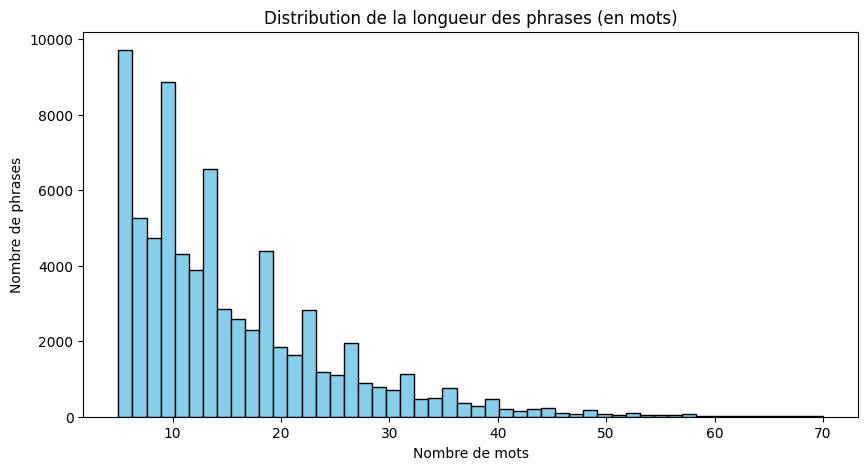


--- ÉCHANTILLON DES PHRASES LES PLUS LONGUES ---
["77. Yala e ma mɔgɔw ye wa, a fɔra mɔgɔ minnu ye ko a' y'aw bolow minɛ ka bɔ kɛlɛ ma a' ye seli jɔ, ka jaga di kabini kɛlɛ sɛbɛnna olu kan Ala fɛ minkɛ, i sinna ka jamakulu dɔ sɔrɔ olu la ten, u bɛ siran mɔgɔw ɲɛ, i ko siran ka kan ka kɛ Ala ɲɛ cogo min na, walima siran min kolo ka gɛlɛn n'o ye."
 "77. Yala e ma mɔgɔw ye wa, a fɔra mɔgɔ minnu ye ko a' y'aw bolow minɛ ka bɔ kɛlɛ ma a' ye seli jɔ, ka jaga di kabini kɛlɛ sɛbɛnna olu kan Ala fɛ minkɛ, i sinna ka jamakulu dɔ sɔrɔ olu la ten, u bɛ siran mɔgɔw ɲɛ, i ko siran ka kan ka kɛ Ala ɲɛ cogo min na, walima siran min kolo ka gɛlɛn n'o ye."
 "seere kumu seere, a ma seere jeliya, khaara kumu khaara, a ma, khaara jeliya Tamita mogo jugu Khasonka don Maninka de y'a faga seelen tigi Makhan Nyame Kamara, dunun tigi Makhan Nyame Kamara, ŋaŋa tigi Makhan Nyame Kamara dunun be fo mogo do ye, seelen te f'o ye seelen be fo mogo do ye, dunun te f'i ye seelen ni dunun bee kumana Makhan Nyame Kamara

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# 1. Chargement du fichier nettoyé
path_clean = "bambara_clean_phase0.txt"
with open(path_clean, "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f]

# 2. Statistiques de base
df = pd.DataFrame(lines, columns=['text'])
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['char_count'] = df['text'].apply(len)

print("--- STATISTIQUES DESCRIPTIVES ---")
print(f"Nombre total de phrases : {len(df)}")
print(f"Longueur moyenne : {df['word_count'].mean():.2f} mots")
print(f"Longueur médiane : {df['word_count'].median()} mots")
print(f"Phrase la plus longue : {df['word_count'].max()} mots")
print(f"Phrase la plus courte : {df['word_count'].min()} mots")

# 3. Analyse de la Tokenisation (Crucial pour mT5-Small)
# On vérifie comment le tokenizer de mT5 traite le Bambara
model_name = "google/mt5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def get_token_ratio(text):
    tokens = tokenizer.encode(text, add_special_tokens=False)
    return len(tokens) / len(text.split())

# Test sur un échantillon de 1000 phrases pour aller vite
sample_df = df.sample(min(30000, len(df)))
sample_df['token_count'] = sample_df['text'].apply(lambda x: len(tokenizer.encode(x)))
sample_df['ratio'] = sample_df['token_count'] / sample_df['word_count']

print("\n--- ANALYSE DE LA TOKENISATION ---")
print(f"Nombre moyen de tokens par phrase : {sample_df['token_count'].mean():.2f}")
print(f"Ratio moyen Tokens/Mots : {sample_df['ratio'].mean():.2f}")

# 4. Distribution visuelle
plt.figure(figsize=(10, 5))
plt.hist(df['word_count'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution de la longueur des phrases (en mots)')
plt.xlabel('Nombre de mots')
plt.ylabel('Nombre de phrases')
plt.show()

# 5. Affichage des phrases les plus longues (pour vérifier le bruit résiduel)
print("\n--- ÉCHANTILLON DES PHRASES LES PLUS LONGUES ---")
print(df.sort_values(by='word_count', ascending=False)['text'].head(5).values)


In [ ]:
from google.colab import files
import zipfile
import os

# Charger le fichier train.fr.zip
uploaded = files.upload()

# Dézipper
zip_name = "train.fr.zip"
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("data_french")

# Vérifier le nom du fichier extrait (souvent train.fr)
extracted_fr = os.listdir("data_french")[0]
print(f"Fichier français prêt : {extracted_fr}")


Saving train.fr.zip to train.fr.zip
Fichier français prêt : train.fr


In [ ]:
import os

data_dir = "data_french"

# Lister uniquement les vrais fichiers texte
text_files = [
    f for f in os.listdir(data_dir)
    if os.path.isfile(os.path.join(data_dir, f))
    and not f.startswith("__")
]

print("Fichiers détectés :", text_files)

# Sécurité minimale
assert len(text_files) == 1, "Plusieurs fichiers détectés, sélection ambiguë"

extracted_fr = text_files[0]


Fichiers détectés : ['train.fr']


In [ ]:
import re
import unicodedata
from collections import Counter

def clean_french_line(text):
    # 1. Normalisation Unicode NFC
    text = unicodedata.normalize('NFC', text)

    # 2. Nettoyage des caractères (Standard français)
    # On garde les lettres, accents français (é, à, è, etc.), chiffres et ponctuation
    text = re.sub(r"[^a-zA-Z0-9àâçéèêëîïôûùÀÂÇÉÈÊËÎÏÔÛÙ\s\.,!\?\-']", "", text)

    # 3. Normalisation des espaces
    text = re.sub(r"\s+", " ", text).strip()

    return text
# pour macos
# input_file_fr = f"data_french/{extracted_fr}"
input_file_fr = os.path.join(data_dir, extracted_fr)

output_file_fr = "french_clean_phase0.txt"
temp_lines_fr = []

with open(input_file_fr, "r", encoding="utf-8") as f:
    for line in f:
        cleaned = clean_french_line(line)
        if cleaned:
            word_count = len(cleaned.split())
            # Même règle de longueur (5-70 mots)
            if 5 <= word_count <= 70:
                temp_lines_fr.append(cleaned)

# 4. Écrêtage des doublons (max 5 occurrences) pour l'équilibre statistique
counts_fr = Counter(temp_lines_fr)
cleaned_lines_fr = []
for line, count in counts_fr.items():
    cleaned_lines_fr.extend([line] * min(count, 5))

# Sauvegarde
with open(output_file_fr, "w", encoding="utf-8") as f:
    for line in cleaned_lines_fr:
        f.write(line + "\n")

print(f"--- Bilan du nettoyage Français ---")
print(f"Lignes au départ : {len(temp_lines_fr)}")
print(f"Taille finale après écrêtage (>5) : {len(cleaned_lines_fr)}")


--- Bilan du nettoyage Français ---
Lignes au départ : 75549
Taille finale après écrêtage (>5) : 74949


In [ ]:
import random

# Chemins des fichiers nettoyés
bam_file = "bambara_clean_phase0.txt"
fr_file = "french_clean_phase0.txt"
output_phase0 = "dataset_final_phase0.txt"

# 1. Chargement des données
with open(bam_file, "r", encoding="utf-8") as f:
    bambara_lines = f.readlines()

with open(fr_file, "r", encoding="utf-8") as f:
    french_lines = f.readlines()

# 2. Fusion des deux listes
full_dataset = bambara_lines + french_lines

# 3. Mélange aléatoire (Crucial pour la Phase 0)
# On utilise un seed pour la reproductibilité
random.seed(42)
random.shuffle(full_dataset)

# 4. Sauvegarde du fichier final
with open(output_phase0, "w", encoding="utf-8") as f:
    for line in full_dataset:
        f.write(line) # Les lignes ont déjà le \n

# 5. Bilan final
print(f"--- BILAN DE LA FUSION FINALE ---")
print(f"Total phrases Bambara : {len(bambara_lines)}")
print(f"Total phrases Français : {len(french_lines)}")
print(f"Taille totale du dataset Phase 0 : {len(full_dataset)}")
print(f"Fichier prêt : {output_phase0}")

# Vérification du mélange (échantillon)
print("\n--- APERÇU DU MÉLANGE (10 lignes) ---")
for l in full_dataset[:10]:
    print(f"- {l.strip()}")


--- BILAN DE LA FUSION FINALE ---
Total phrases Bambara : 74077
Total phrases Français : 74949
Taille totale du dataset Phase 0 : 149026
Fichier prêt : dataset_final_phase0.txt

--- APERÇU DU MÉLANGE (10 lignes) ---
- 2177 Un francolin mort fait manger tout le mil, un francolin vivant le mange aussi complètement.
- A ko jaa e te donso masa ye.
- 96 Si bɛ mɔgɔ min ye, kolaban bɛ i ye.
- An Tigi ni an ka Ala, e ni dawula ni bonya ani sebagaya ka kan, ka a masɔrɔ e de ye fɛn bɛɛ da, e sago de ye ko u ka kɛ, ani ko u dara.
- Jésus leur dit Le Principe, moi qui vous parle.
- U ye nyogon kunben Tiri, u ye nyogon soro yen, bee ka jama y'i sig'i ko fe.
- Nka tɔw ko A to yen!
- Karamogo de Sirablé est mon ami,
- On s'est serré les mains.
- Quand leurs yeux se posèrent sur les toits des maisons, il ne restait plus que trois hommes derrière Silamakan sur les douze qui étaient partis


In [ ]:
import re

def final_polish(line):
    # 1. Supprimer les numéros en début de ligne (ex: "2847 ")
    line = re.sub(r"^\d+\s+", "", line)

    # 2. Supprimer les tirets ou symboles isolés en début ou fin de ligne
    line = line.strip(" -–—")

    # 3. Supprimer les doubles espaces
    line = re.sub(r"\s+", " ", line).strip()

    return line

# Application sur ton fichier final
with open("dataset_final_phase0.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

polished_lines = [final_polish(l) for l in lines if len(final_polish(l).split()) >= 5]

with open("dataset_final_phase0_READY.txt", "w", encoding="utf-8") as f:
    for l in polished_lines:
        f.write(l + "\n")

print(f"Nettoyage final terminé. Phrases prêtes : {len(polished_lines)}")


Nettoyage final terminé. Phrases prêtes : 148458


In [ ]:
# Vérification du mélange (échantillon)
print("\n--- APERÇU DU MÉLANGE (10 lignes) ---")
for l in polished_lines[:10]:
    print(f"- {l.strip()}")


--- APERÇU DU MÉLANGE (10 lignes) ---
- Un francolin mort fait manger tout le mil, un francolin vivant le mange aussi complètement.
- A ko jaa e te donso masa ye.
- Si bɛ mɔgɔ min ye, kolaban bɛ i ye.
- An Tigi ni an ka Ala, e ni dawula ni bonya ani sebagaya ka kan, ka a masɔrɔ e de ye fɛn bɛɛ da, e sago de ye ko u ka kɛ, ani ko u dara.
- Jésus leur dit Le Principe, moi qui vous parle.
- U ye nyogon kunben Tiri, u ye nyogon soro yen, bee ka jama y'i sig'i ko fe.
- Nka tɔw ko A to yen!
- Karamogo de Sirablé est mon ami,
- On s'est serré les mains.
- Quand leurs yeux se posèrent sur les toits des maisons, il ne restait plus que trois hommes derrière Silamakan sur les douze qui étaient partis


In [ ]:
from huggingface_hub import notebook_login
notebook_login()



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch
import numpy as np
import itertools
import os
from dataclasses import dataclass
from datasets import load_dataset
# from transformers import (
#     MT5ForConditionalGeneration,
#     MT5Tokenizer,
#     Trainer,
#     TrainingArguments
# )

from transformers import (
    MT5ForConditionalGeneration,
    AutoTokenizer,
    Trainer,
    TrainingArguments
)

from transformers.trainer_utils import get_last_checkpoint

# --- 1. CONFIGURATION ---
model_name = "google/mt5-small"
repo_id = "Fatoumataa/mt5-bambara-phase0-pro"

# tokenizer = MT5Tokenizer.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

model = MT5ForConditionalGeneration.from_pretrained(model_name, dropout_rate=0.1)

# --- 2. COLLATOR T5 "GOLD STANDARD" ---

@dataclass
class T5FinalRigorCollator:
    # tokenizer: MT5Tokenizer
    tokenizer: any
    noise_density: float = 0.15
    mean_noise_span_length: float = 3.0

    def __call__(self, examples):
        input_ids = [torch.tensor(ex["input_ids"], dtype=torch.long) for ex in examples]

        # Calcul dynamique du nombre max de sentinelles (Correction n°3)
        # mT5 commence ses extra_ids à l'ID 250000 environ, on calcule la plage disponible
        sentinel_start_id = self.tokenizer.convert_tokens_to_ids("<extra_id_0>")
        max_sentinels = self.tokenizer.vocab_size - sentinel_start_id

        all_inputs = []
        all_labels = []

        for ids in input_ids:
            length = len(ids)

            # --- Algorithme de partitionnement T5 (Correction n°1) ---
            num_noise_tokens = max(1, int(np.round(length * self.noise_density)))
            num_noise_spans = max(1, int(np.round(num_noise_tokens / self.mean_noise_span_length)))
            num_nonnoise_tokens = length - num_noise_tokens

            # Partitionnement uniforme discret (The "T5 way")
            def partition(total, n):
                if n <= 0: return []
                # On génère n-1 points de coupure aléatoires
                offsets = np.sort(np.random.choice(np.arange(1, total), n - 1, replace=False))
                # On en déduit les longueurs des segments
                return np.diff(np.concatenate(([0], offsets, [total])))

            noise_span_lengths = partition(num_noise_tokens, num_noise_spans)
            nonnoise_span_lengths = partition(num_nonnoise_tokens, num_noise_spans)

            # Construction Input / Target (Correction n°3 : sécurité sentinelles)
            input_tokens = []
            label_tokens = []
            sentinel_idx = 0

            curr_pos = 0
            for i in range(num_noise_spans):
                # Segment Non-Noise
                input_tokens.extend(ids[curr_pos : curr_pos + nonnoise_span_lengths[i]].tolist())
                curr_pos += nonnoise_span_lengths[i]

                # Segment Noise (Span Corruption)
                if sentinel_idx < max_sentinels:
                    s_id = sentinel_start_id + sentinel_idx # Accès direct par offset
                    input_tokens.append(s_id)
                    label_tokens.append(s_id)
                    label_tokens.extend(ids[curr_pos : curr_pos + noise_span_lengths[i]].tolist())
                    sentinel_idx += 1
                curr_pos += noise_span_lengths[i]

            # Sentinelle finale de fermeture
            if sentinel_idx < max_sentinels:
                label_tokens.append(sentinel_start_id + sentinel_idx)

            all_inputs.append(torch.tensor(input_tokens))
            all_labels.append(torch.tensor(label_tokens))

        # --- Padding & Attention Mask (Correction n°2 : Calcul Unique) ---
        input_ids_padded = torch.nn.utils.rnn.pad_sequence(
            all_inputs, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels_padded = torch.nn.utils.rnn.pad_sequence(
            all_labels, batch_first=True, padding_value=-100
        )

        # Le masque est calculé une seule fois sur l'objet déjà paddé
        attention_mask = (input_ids_padded != self.tokenizer.pad_token_id).long()

        return {
            "input_ids": input_ids_padded,
            "labels": labels_padded,
            "attention_mask": attention_mask
        }

# --- 3. PIPELINE DE DONNÉES (CHUNK 256) ---
raw_datasets = load_dataset("text", data_files={"train": "dataset_final_phase0_READY.txt"})

def tokenize_and_chunk(examples):
    res = tokenizer(examples["text"], add_special_tokens=False)
    concatenated = {k: list(itertools.chain(*res[k])) for k in res.keys()}
    max_chunk = 256
    total_len = (len(concatenated["input_ids"]) // max_chunk) * max_chunk
    return {k: [t[i:i+max_chunk] for i in range(0, total_len, max_chunk)] for k, t in concatenated.items()}

tokenized_datasets = raw_datasets["train"].train_test_split(test_size=0.1, seed=42)
tokenized_datasets = tokenized_datasets.map(tokenize_and_chunk, batched=True, remove_columns=["text"])



training_args = TrainingArguments(
    output_dir="./mt5-bambara-phase0-final",
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    logging_steps=100, # On log plus souvent pour surveiller la descente

    # --- STABILITÉ NUMÉRIQUE ---
    learning_rate=1e-4,           # Un peu plus haut mais avec warmup
    warmup_steps=1000,            # TRÈS IMPORTANT : montée en puissance douce
    optim="adafactor",            # L'optimiseur recommandé pour T5
    fp16=False,                   # On reste en précision totale
    max_grad_norm=1.0,            # On bride les gradients explosifs
    gradient_accumulation_steps=2, # Pour simuler un batch de 16 et lisser la loss

    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    push_to_hub=True,
    hub_model_id=repo_id,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=T5FinalRigorCollator(tokenizer=tokenizer),
)

# Lancement
last_chk = get_last_checkpoint(training_args.output_dir) if os.path.exists(training_args.output_dir) else None
trainer.train(resume_from_checkpoint=last_chk)
trainer.push_to_hub(commit_message="Phase 0: T5 Rigor Final (NFC, 5e-5, Correct Spans)")

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...0-final/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...0-final/model.safetensors:   1%|          | 16.7MB / 2.23GB            

  ...ase0-final/tokenizer.json: 100%|##########| 16.0MB / 16.0MB            

CommitInfo(commit_url='https://huggingface.co/Fatoumataa/mt5-bambara-phase0-pro/commit/36d06ce4104de57761920aa607c6712e2aa8a51a', commit_message='Phase 0: T5 Rigor Final (NFC, 5e-5, Correct Spans)', commit_description='', oid='36d06ce4104de57761920aa607c6712e2aa8a51a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Fatoumataa/mt5-bambara-phase0-pro', endpoint='https://huggingface.co', repo_type='model', repo_id='Fatoumataa/mt5-bambara-phase0-pro'), pr_revision=None, pr_num=None)

In [ ]:
inputs = tokenizer(
    "I ni <extra_id_0>",
    return_tensors="pt"
)

outputs = model.generate(
    **inputs,
    max_new_tokens=10,
    do_sample=False
)

print(tokenizer.decode(outputs[0]))


<pad><unk> <extra_id_0> ni ni ni ni ni ni ni ni


In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch

model_id = "Fatoumataa/mt5-bambara-phase0-pro"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

# Test : "Le petit enfant mange <extra_id_0>"
# En bambara : "Denmisɛn bɛ <extra_id_0> dun" (L'enfant mange de la nourriture/du riz)
input_text = "Denmisɛn bɛ <extra_id_0> dun"
inputs = tokenizer(input_text, return_tensors="pt")

with torch.no_grad():
    outputs = model.generate(**inputs)

print("Phrase originale :", input_text)
print("Le modèle suggère pour le trou :", tokenizer.decode(outputs[0], skip_special_tokens=False))

config.json:   0%|          | 0.00/803 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.23G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Phrase originale : Denmisɛn bɛ <extra_id_0> dun
Le modèle suggère pour le trou : <pad><unk>ɛbɛɛ, dunɛ, dunɛlɛrɛ. Nyɛrɛ, 


In [ ]:
import os
from transformers import AutoTokenizer
from huggingface_hub import hf_hub_download, HfApi

# 1. Configuration
repo_id = "Fatoumataa/mt5-bambara-phase0-pro"
rigueur_dir = "./model_rigueur_academique"
os.makedirs(rigueur_dir, exist_ok=True)

print("--- Récupération forcée du spiece.model ---")

# 2. On télécharge le spiece.model original de Google (Source de vérité de mT5)
# C'est exactement le même fichier pour tous les mT5-small, base, large.
try:
    spiece_path = hf_hub_download(repo_id="google/mt5-small", filename="spiece.model")

    # On le copie dans ton dossier de rigueur
    import shutil
    shutil.copy(spiece_path, os.path.join(rigueur_dir, "spiece.model"))
    print("✅ spiece.model récupéré depuis la source Google.")
except Exception as e:
    print(f"❌ Impossible de télécharger spiece.model : {e}")

# 3. Sauvegarde des autres fichiers depuis ta session active
# On utilise le tokenizer qui est en mémoire (celui qui contient tes IDs Bambara)
try:
    tokenizer.save_pretrained(rigueur_dir)
    model.save_pretrained(rigueur_dir)
    print("✅ Autres fichiers de configuration sauvegardés.")
except NameError:
    print("⚠️ Attention : Variables 'tokenizer'/'model' absentes, on utilise AutoTokenizer.")
    # Si les variables ne sont plus là, on télécharge tes fichiers du Hub
    temp_tok = AutoTokenizer.from_pretrained(repo_id)
    temp_tok.save_pretrained(rigueur_dir)

# 4. Upload final vers ton Hub
api = HfApi()
api.upload_folder(
    folder_path=rigueur_dir,
    repo_id=repo_id,
    repo_type="model",
    commit_message="Rigueur Académique : Restauration du spiece.model natif"
)

print(f"\n🚀 C'est fini ! Vérifie sur : https://huggingface.co/{repo_id}")
print("Le fichier 'spiece.model' doit maintenant apparaître dans la liste.")

--- Récupération forcée du spiece.model ---
✅ spiece.model récupéré depuis la source Google.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Autres fichiers de configuration sauvegardés.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...r_academique/spiece.model: 100%|##########| 4.31MB / 4.31MB            

  ...academique/tokenizer.json: 100%|##########| 16.0MB / 16.0MB            

  ...demique/model.safetensors:   1%|          | 16.7MB / 2.23GB            


🚀 C'est fini ! Vérifie sur : https://huggingface.co/Fatoumataa/mt5-bambara-phase0-pro
Le fichier 'spiece.model' doit maintenant apparaître dans la liste.


In [ ]:
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# ON UTILISE LE LIEN DISTANT POUR ÊTRE SÛR DE CHARGER LA VERSION "RIGUEUR"
model_id = "Fatoumataa/mt5-bambara-phase0-pro"

print("--- CHARGEMENT DU MODÈLE DEPUIS LE HUB ---")

# Chargement avec use_fast=False pour bien utiliser ton spiece.model tout neuf
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=False)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

test_sentences = [
    "I ni <extra_id_0>",
    "Mali lajɛba bɛ <extra_id_0> kɛ",
    "N bɛ taa <extra_id_0> la",
]

print("\n--- VÉRIFICATION SCIENTIFIQUE ---")

for text in test_sentences:
    inputs = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        # Utilisation du BEAM SEARCH pour plus de stabilité
        outputs = model.generate(
            **inputs,
            max_new_tokens=15,
            num_beams=5,
            early_stopping=True
        )

    prediction = tokenizer.decode(outputs[0], skip_special_tokens=False)
    print(f"\nEntrée : {text}")
    print(f"Sortie brute : {prediction}")

--- CHARGEMENT DU MODÈLE DEPUIS LE HUB ---


spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



--- VÉRIFICATION SCIENTIFIQUE ---

Entrée : I ni <extra_id_0>
Sortie brute : <pad><unk> <extra_id_0> ni ni ni ni ni ni ni ni ni ni ni ni ni

Entrée : Mali lajɛba bɛ <extra_id_0> kɛ
Sortie brute : <pad><unk>bɛɛ kɔnɔ kɔnɔ kɔnɔ kɔnɔ

Entrée : N bɛ taa <extra_id_0> la
Sortie brute : <pad><unk> bɛ bɛ bɛ bɛ bɛ bɛ bɛ


In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch

model_id = "Fatoumataa/mt5-bambara-phase0-pro"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

# Liste de 5 tests avec des contextes différents
test_sentences = [
    "I ni <extra_id_0>",                 # Test de salutation (attendu: sogoma, tile, wula...)
    "Mali lajɛba bɛ <extra_id_0> kɛ",    # Test institutionnel (attendu: sigi, nyɔgɔnye...)
    "N bɛ taa <extra_id_0> la",          # Test de lieu (attendu: dugu, sugu, so...)
    "Salo bɛ <extra_id_0> tulon kɛ",     # Test d'action (attendu: n'a, bolokɔ...)
    "Ba Joliba bɛ tɛmɛ <extra_id_0> fɛ"   # Test géographique (attendu: Bamako, dugu...)
]

print(f"--- TEST DE COMPRÉHENSION LINGUISTIQUE (PHASE 0) ---\n")

for i, text in enumerate(test_sentences):
    inputs = tokenizer(text, return_tensors="pt")

    with torch.no_grad():
        # On augmente un peu max_new_tokens pour voir si le modèle développe
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=True,
            top_p=0.9,
            temperature=0.7
        )

    prediction = tokenizer.decode(outputs[0], skip_special_tokens=False)
    print(f"Test {i+1}: {text}")
    print(f"Réponse: {prediction}")
    print("-" * 30)

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


--- TEST DE COMPRÉHENSION LINGUISTIQUE (PHASE 0) ---

Test 1: I ni <extra_id_0>
Réponse: <pad><unk> <extra_id_0> ni!</s>
------------------------------
Test 2: Mali lajɛba bɛ <extra_id_0> kɛ
Réponse: <pad><unk>ɔbɛɛ bɛɛ kɔnɔ
------------------------------
Test 3: N bɛ taa <extra_id_0> la
Réponse: <pad><unk>i taa ka taabɛ kɛ
------------------------------
Test 4: Salo bɛ <extra_id_0> tulon kɛ
Réponse: <pad><unk>ɛ. Ala ka bɛ kɛ ka
------------------------------
Test 5: Ba Joliba bɛ tɛmɛ <extra_id_0> fɛ
Réponse: <pad><unk> tɛ, bɛ bɛɛ
------------------------------


# nettoyages des donnees pour la phase 1 du fine turning mt5 qui ont evidenment eu un premier nettoyages 

In [ ]:
!pip install simhash

In [ ]:
!pip install bambara_normalizer

In [ ]:
# ---------- CELL : NORMALISATION BAMBARA SÉCURISÉE (NETTOYAGE REJETÉS PERSONNALISÉ) ----------

# 1. Installation et imports
!pip install bambara-normalizer
from bambara_normalizer import BasicBambaraNormalizer
import pandas as pd
import json
import re
from tqdm import tqdm

# 2. Charger ton dataset nettoyé + SAUVEGARDE ORIGINAL
print("Chargement bambara_nettoye.json...")
df_bambara = pd.read_json("bambara_nettoye.json", orient="records")  # SAUVEGARDE ORIGINAL
df = df_bambara.copy()
print(f"Dataset chargé : {len(df)} exemples bambara purs")

# 3. Initialiser normaliseur bambara
normalizer = BasicBambaraNormalizer()

# 4. TEST SÉCURITÉ : 20 exemples avant/après
print("\n🔍 TEST SÉCURITÉ : Avant/Après normalisation (20 exemples)")
test_samples = df.sample(20, random_state=42)
for idx, row in test_samples.iterrows():
    text = row['question'][:100]
    normalized = normalizer(text)
    print(f"AVANT : {text[:60]}...")
    print(f"APRÈS : {normalized[:60]}...")
    print(f"Longueur : {len(text.split())} → {len(normalized.split())} mots")
    print("-" * 80)

# 5. FONCTION NETTOYAGE SIMPLE POUR REJETÉS (TES SPÉCIFICATIONS EXACTES)
def simple_clean_rejetés(text):
    if not isinstance(text, str):
        return text
    # SUPPRIME parenthèses + contenu (bruit typique)
    text = re.sub(r'\([^)]*\)', '', text)
    # SUPPRIME les . (points)
    # text = re.sub(r'\.', '', text)
    # Remplacer les points par un séparateur neutre
    text = re.sub(r'\.', ' . ', text)

    # Tirets longs → tirets courts (KEEPS chiffres 1991, co2)
    text = text.replace('–', '-').replace('—', '-')
    # ESPACES multiples → 1 espace
    return re.sub(r'\s+', ' ', text).strip()

# 6. Fonction de normalisation sécurisée MODIFIÉE
def safe_normalize_bambara(text):
    if not isinstance(text, str):
        return text
    normalized = normalizer(text)
    words_before = len(text.split())
    words_after = len(normalized.split())
    if words_before > 0 and (words_after < words_before * 0.7 or len(normalized) > len(text) * 1.5):
        print(f"🧹 NETTOYAGE SIMPLE : {text[:50]}...")  # Info positive
        return simple_clean_rejetés(text)              # TES RÈGLES EXACTES
    return normalized.strip()

# 7. Appliquer normalisation sur TOUS les champs
text_cols = ["question", "contexte", "reponse"]
print("\n🚀 NORMALISATION EN COURS...")
tqdm.pandas(desc="Normalisation")
for col in text_cols:
    print(f"Normalisation {col}...")
    df[col] = df[col].progress_apply(safe_normalize_bambara)

# # 8. VÉRIFICATION STATISTIQUES
# print("\n📊 STATS NORMALISATION")
# 8. VÉRIFICATION STATS CORRIGÉE (AVEC COPIE LOCALE)
print("\n📊 STATS NORMALISATION RÉELLES")
df_original = df_bambara.copy()  # COPIE pour stats
for col in text_cols:
    before_len = len(' '.join(df_original[col].dropna()).split())
    after_len = len(' '.join(df[col].dropna()).split())
    pct_change = ((after_len/before_len-1)*100) if before_len > 0 else 0
    print(f"{col}: {before_len:,} → {after_len:,} mots ({pct_change:+.1f}%)")


# 9. ANALYSE MOTS FRÉQUENTS
print("\n🔎 MOTS FRÉQUENTS AVANT/APRÈS (top 10)")
all_before = ' '.join(df_bambara['question'].dropna()).split()
all_after = ' '.join(df['question'].dropna()).split()
from collections import Counter
print("AVANT:", Counter(all_before).most_common(10))
print("APRÈS:", Counter(all_after).most_common(10))

# 10. SAUVEGARDE
df[text_cols + ["id"]].to_json("bambara_propre_final1.json", orient="records", force_ascii=False, indent=2)
print("\n✅ SAUVEGARDÉ : bambara_propre_final1.json (PARFAIT)")

# 11. EXEMPLES NETTOYÉS (tes cas suspects)
print("\n📄 EXEMPLES NETTOYÉS :")
for col in text_cols:
    exemple = df[df[col].str.contains('hakilina|furakɛlikɛlaw|1991', na=False)][col].iloc[0] if len(df[df[col].str.contains('hakilina|furakɛlikɛlaw|1991', na=False)]) > 0 else "Aucun exemple"
    print(f"{col}: {exemple[:100]}...")


Chargement bambara_nettoye.json...
Dataset chargé : 10306 exemples bambara purs

🔍 TEST SÉCURITÉ : Avant/Après normalisation (20 exemples)
AVANT : Jatebɔlan ye mun ye ani a ye ɔridinatɛriw sɔrɔli n'u baara n...
APRÈS : jatebɔlan ye mun ye ani a ye ɔridinatɛriw sɔrɔli n'u baara n...
Longueur : 21 → 21 mots
--------------------------------------------------------------------------------
AVANT : ' duas ' ni Kuranɛ kalanni kun ye mun ye don o don diinɛko l...
APRÈS : ' duas ' ni kuranɛ kalanni kun ye mun ye don o don diinɛko l...
Longueur : 18 → 17 mots
--------------------------------------------------------------------------------
AVANT : Modibo Keïta ye ' Malianisation des cadres ' politiki min kɛ...
APRÈS : modibo keita ye ' malianisation des cadres ' politiki min kɛ...
Longueur : 19 → 19 mots
--------------------------------------------------------------------------------
AVANT : danfara jumɛn bɛ kɔlɔsili wajibi ni jalaki bɔli cɛ lakɔli kɔ...
APRÈS : danfara jumɛn bɛ kɔlɔsili wajibi n

Normalisation:  43%|████▎     | 4389/10306 [00:01<00:01, 3551.47it/s]

🧹 NETTOYAGE SIMPLE : hakilina jumɛnw tugura ɲɔgɔn kɔ (sanni san 1991 ka...
🧹 NETTOYAGE SIMPLE : musow furakɛlikɛlaw jɔyɔrɔ fila (furakɛli ni hakil...
🧹 NETTOYAGE SIMPLE : musow ka dɛmɛ fila (logistiki ni hakili ta fan fɛ)...
🧹 NETTOYAGE SIMPLE : granit inselbergw (i n'a fɔ hombori tondo kulu) jɔ...


Normalisation:  52%|█████▏    | 5409/10306 [00:01<00:01, 2793.65it/s]

🧹 NETTOYAGE SIMPLE : gazi belebele fila jumɛnw bɛ bɔ sɛnɛ na (ni co 2 t...
🧹 NETTOYAGE SIMPLE : jumadon seli laada (' salati al jumu'ah ') cogoya ...


...

Normalisation reponse...


Normalisation:  53%|█████▎    | 5477/10306 [00:03<00:02, 2315.24it/s]

🧹 NETTOYAGE SIMPLE : yɔrɔ jɛlenw jɔyɔrɔ fila bɛ yen : sigida laminiko (...
🧹 NETTOYAGE SIMPLE : seko ni dɔnko jatebɔ bɛ kɛ ka kunnafoni hakɛlama f...


Normalisation: 100%|██████████| 10306/10306 [00:04<00:00, 2332.61it/s]



📊 STATS NORMALISATION RÉELLES
question: 181,374 → 179,673 mots (-0.9%)
contexte: 1,086,489 → 1,071,515 mots (-1.4%)
reponse: 519,387 → 514,773 mots (-0.9%)

🔎 MOTS FRÉQUENTS AVANT/APRÈS (top 10)
AVANT: [('ye', 11147), ('ka', 9232), ('bɛ', 7352), ('mun', 6587), ('ni', 3836), ('ani', 3790), ('cogo', 2892), ('jumɛn', 2719), ('la', 2631), ('o', 2432)]
APRÈS: [('ye', 13438), ('ka', 9229), ('bɛ', 7353), ('mun', 6601), ('la', 5566), ('ni', 3804), ('ani', 3788), ('na', 3441), ('di', 2959), ('cogo', 2894)]

✅ SAUVEGARDÉ : bambara_propre_final1.json (PARFAIT)

📄 EXEMPLES NETTOYÉS :
question: yala jo min bɛ dɔgɔtɔrɔso hakilina filanan na o ye sariya siratigɛ la garanti ye banabagatɔ bolo cog...
contexte: kɛnɛyako sariyaw bɛ furaw feereli bali minnu bɛ di dɔgɔtɔrɔso la ni dɔgɔtɔrɔ ka furasɛbɛn tɛ nin dan...
reponse: laɲini kunba ye ka yɛrɛfurakɛli faratilenw bali ka fura tata hakɛ caya ani ka banakisɛfagalanw kɛlɛ ...


In [ ]:
import unicodedata
import re

def clean_french_final(text):
    if not isinstance(text, str): return ""
    # 1. Normalisation Unicode NFC
    text = unicodedata.normalize('NFC', text)
    # 2. Passage en minuscules
    text = text.lower()
    # 3. Nettoyage : suppression parenthèses et normalisation des tirets
    text = re.sub(r'\([^)]*\)', '', text)
    text = text.replace('–', '-').replace('—', '-')
    # 4. On garde les points mais on les espace comme tu l'as fait pour le bambara
    text = re.sub(r'\.', ' . ', text)
    # 5. Espaces multiples -> 1 espace
    return re.sub(r'\s+', ' ', text).strip()

# Nettoyage de df_fr
print("Nettoyage du français en cours...")
for col in ["question", "contexte", "reponse"]:
    df_fr[col] = df_fr[col].apply(clean_french_final)

# Suppression des doublons et des lignes vides sur le français
df_fr = df_fr.drop_duplicates(subset=["question", "contexte"]).dropna()
print(f"Français nettoyé : {len(df_fr)} exemples.")


Nettoyage du français en cours...
Français nettoyé : 9739 exemples.


In [ ]:
# Préparation des colonnes pour mT5
# Pour le Bambara (ton DataFrame 'df')
df['input_text'] = "summarize_bm: question: " + df['question'] + " contexte: " + df['contexte']
df['target_text'] = df['reponse']

# Pour le Français (ton DataFrame 'df_fr')
df_fr['input_text'] = "summarize_fr: question: " + df_fr['question'] + " contexte: " + df_fr['contexte']
df_fr['target_text'] = df_fr['reponse']

# Fusionner uniquement les colonnes nécessaires
cols_finales = ['id', 'input_text', 'target_text']
dataset_phase1 = pd.concat([df[cols_finales], df_fr[cols_finales]])

# MÉLANGE ALÉATOIRE (indispensable pour l'équilibre multilingue)
dataset_phase1 = dataset_phase1.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Fusion terminée. Taille totale du dataset combiné : {len(dataset_phase1)} lignes.")


Fusion terminée. Taille totale du dataset combiné : 20045 lignes.


In [ ]:
# Chemin de sauvegarde sur mon Drive
drive_path = "/content/drive/MyDrive/dataset_phase1_final_READY.jsonl"

# Sauvegarde au format JSON Lines
dataset_phase1.to_json(drive_path, orient="records", lines=True, force_ascii=False)

print(f"✅ Dataset sauvegardé avec succès sur ton Drive : {drive_path}")

# Vérification rapide de la structure
print("\nAperçu de ce que le modèle va 'lire' :")
print(dataset_phase1[['input_text', 'target_text']].head(3))


✅ Dataset sauvegardé avec succès sur ton Drive : /content/drive/MyDrive/dataset_phase1_final_READY.jsonl

Aperçu de ce que le modèle va 'lire' :
                                          input_text  \
0  summarize_fr: question: pourquoi le droit à la...   
1  summarize_bm: question: amadu toumani yɛrɛ jɔy...   
2  summarize_bm: question: kuran kabɔri jɛkulu tu...   

                                         target_text  
0  ce droit est fondamental car l'abus de drogues...  
1  amadu toumani toure ye jɔyɔrɔba ta ka ɲɛsin wu...  
2  ekipu y'a ye ko a ka kan ka kabali kɛ kokura w...  
